## Reasoning over time

In [1]:
# required modules (under Anaconda use: > conda install -c conda-forge <package>)
if False: # (skip if already installed)
    !pip install lark-parser
    !pip install linear-tree
    !pip install pydot
    !pip install pydotplus
    !pip install hopsy
    !pip install janus-swi
    # download and install SWI Prolog from https://www.swi-prolog.org/download/stable

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# standard imports
import os
import sys
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score

# black-box model imports
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Using janus - set SWI Prolog home
SWI_HOME = r"C:\Program Files\swipl"
os.environ["SWI_HOME_DIR"] = SWI_HOME
os.add_dll_directory(os.path.join(SWI_HOME, "bin"))

# local imports
sys.path.append('../src/') # local path
import reasonx
import dautils
from helper_functions import read_adult

# for reproducibility
random.seed(42)
np.random.seed(42)

# set to False to remove assertion check
assertion_check = True

In [3]:
# Loading the dataset
df, pred_atts, target, df_code = read_adult(continuous_only=False, simplified=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   race          48842 non-null  str  
 1   sex           48842 non-null  str  
 2   workclass     48842 non-null  str  
 3   education     48842 non-null  str  
 4   age           48842 non-null  int64
 5   capitalgain   48842 non-null  int64
 6   capitalloss   48842 non-null  int64
 7   hoursperweek  48842 non-null  int64
 8   class         48842 non-null  str  
dtypes: int64(4), str(5)
memory usage: 3.4 MB


In [4]:
# Encoding the dataset
df_encoded_onehot = df_code.fit_transform(df)
encoded_pred_atts = df_code.encoded_atts(pred_atts)
df_encoded_onehot.head()

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,...,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek,class
0,False,False,False,False,True,False,True,False,False,False,...,False,False,True,False,13,39,2174,0,40,0
1,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,13,50,0,0,13,0
2,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,9,38,0,0,40,0
3,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,7,53,0,0,40,0
4,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,13,28,0,0,40,0


### Train models on different data distributions

In [5]:
# split predictive and target
X, y = df_encoded_onehot[encoded_pred_atts], df_encoded_onehot[target]
# split data set to simulate different data distributions
X_sub1, X_sub2, y_sub1, y_sub2 = train_test_split(X, y, test_size=0.5, random_state=42)
# retain test sets
X1, XT1, y1, yt1 = train_test_split(X, y, test_size=0.65, random_state=55) # smaller training as to increase variability
X2, XT2, y2, yt2 = train_test_split(X, y, test_size=0.65, random_state=66) # over the two DTs

# train a decision tree
clf2 = DecisionTreeClassifier(max_depth=3)
clf2.fit(X1, y1)
clf1 = DecisionTreeClassifier(max_depth=3)
clf1.fit(X2, y2)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

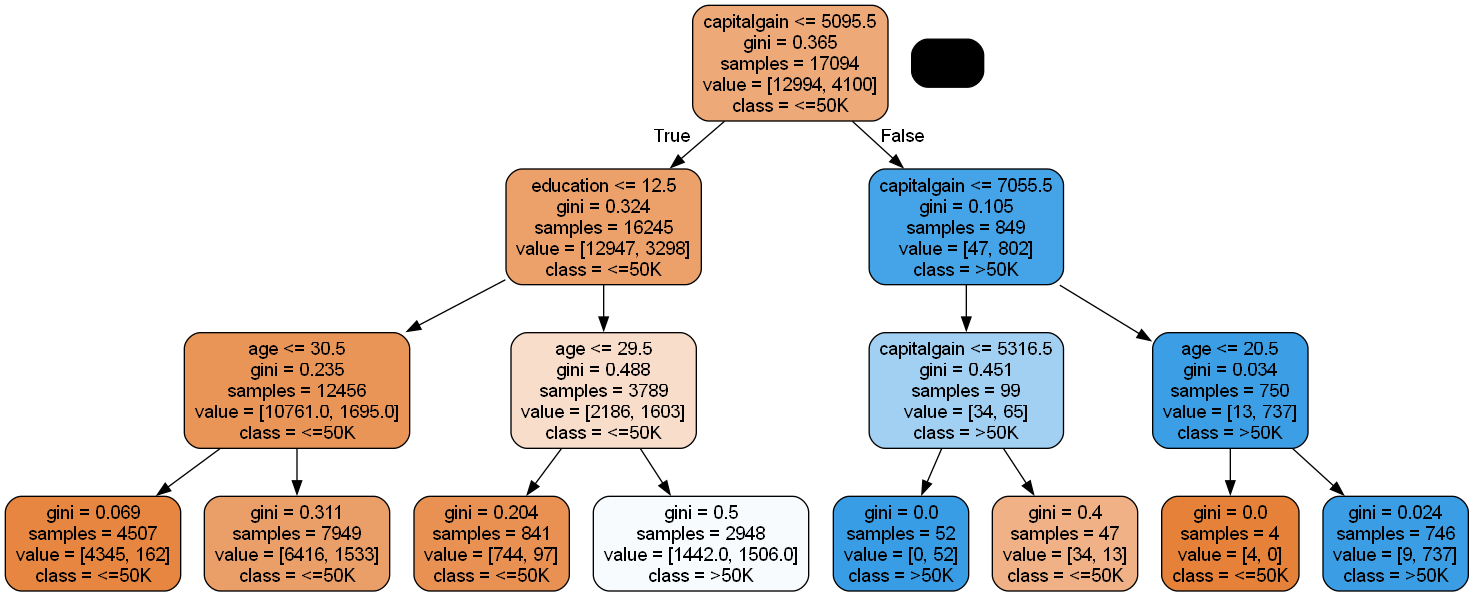

In [6]:
from sklearn import tree
import pydotplus
from IPython.display import Image

# visualize the decision tree
dot_data = tree.export_graphviz(clf1, out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

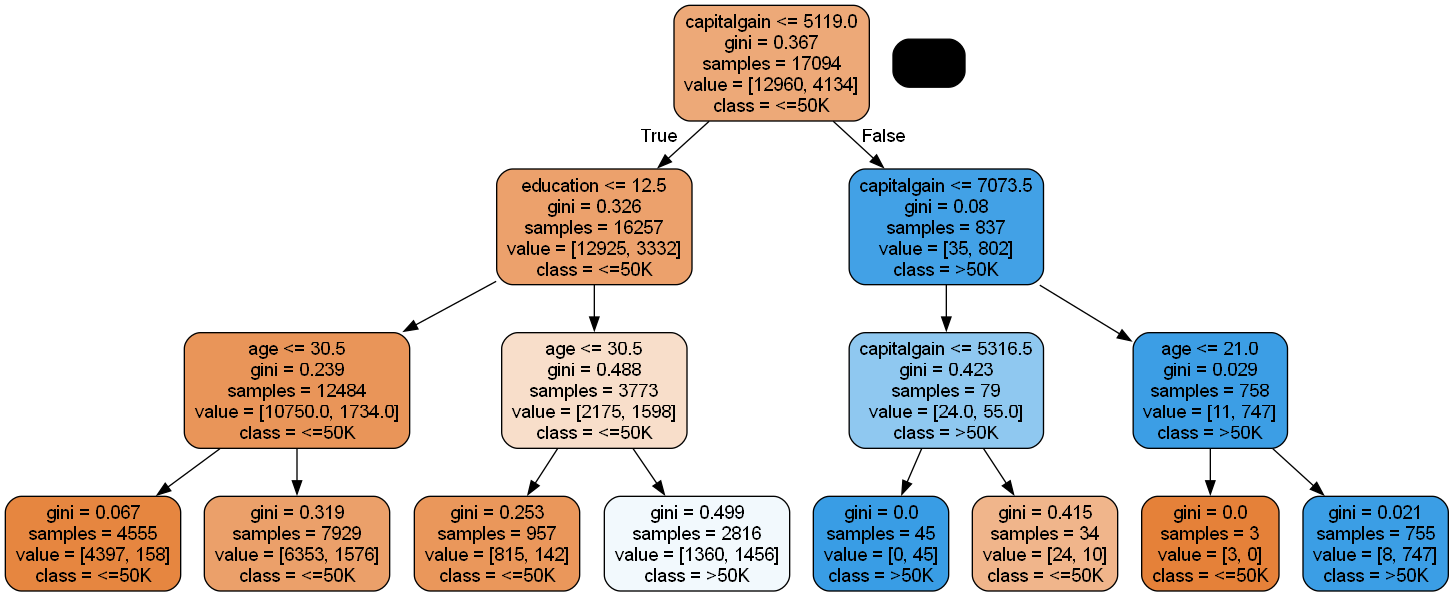

In [7]:
# visualize the decision tree clf2
dot_data = tree.export_graphviz(clf2, out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

### Explain

In [8]:
# initialise ReasonX
r = reasonx.ReasonX(pred_atts, target, df_code)
model1 = r.model(clf1, returnID=True)
model2 = r.model(clf2, returnID=True)

In [9]:
# intersection of the two test sets
XT_shared = XT1.index.intersection(XT2.index)
len(XT_shared)

20610

In [10]:
# fix instance to explain
idx = 35498
assert idx in XT_shared # choose a row from the intersection of XT1 and XT2 (=whose index is in XT_shared)
inst = XT1.index.get_loc(idx)
print(inst)
x_features = XT1.iloc[inst:(inst+1)]
x_class = yt1.iloc[inst]
x_features

10787


,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,workclass_Private,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek
35498,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,9,61,0,0,50


In [11]:
# diff models but compare over SAME data instace
# factual decision rule
r.instance('F0', features=x_features, label=x_class, model=model1)
r.instance('F1', features=x_features, label=x_class, model=model2)
r.solveopt()

---
Answer constraint: F0.race=White,F0.sex=Male,F0.workclass=Private,F0.education=9.0,F0.age=61.0,F0.capitalgain=0.0,F0.capitalloss=0.0,F0.hoursperweek=50.0,F1.race=White,F1.sex=Male,F1.workclass=Private,F1.education=9.0,F1.age=61.0,F1.capitalgain=0.0,F1.capitalloss=0.0,F1.hoursperweek=50.0
Rule satisfied by F0: IF F0.capitalgain<=5095.5,F0.education<=12.5,F0.age>30.5 THEN <=50K [0.8071, 0.4650]
Rule satisfied by F1: IF F1.capitalgain<=5119.0,F1.education<=12.5,F1.age>30.5 THEN <=50K [0.8012, 0.4638]


In [12]:
# contrastive explanations -- instance F0
print("contrastive explanations wrt F0")
r.instance('CE0', label=1-x_class, model=model1, minconf=0.8)
r.constraint("CE0.race = F0.race, CE0.sex = F0.sex, CE0.workclass = F0.workclass, CE0.education >= F0.education, CE0.age >= F0.age")
r.solveopt(project=['CE0'])
CE0_answers = r.answers()
if assertion_check:
    assert CE0_answers == ['CE0.race=White,CE0.sex=Male,CE0.workclass=Private,CE0.education>=9.0,CE0.age>=61.0,CE0.capitalgain>5095.5,CE0.capitalgain<=5316.5',
                      'CE0.race=White,CE0.sex=Male,CE0.workclass=Private,CE0.education>=9.0,CE0.age>=61.0,CE0.capitalgain>7055.5']
print("\n\nminimal contrastive explanations wrt F0")
r.solveopt(minimize='l1norm(F0, CE0)', project=['CE0'], eps=0.01)
MCE0_answers = r.answers()
if assertion_check:
    assert MCE0_answers == ['CE0.race=White,CE0.sex=Male,CE0.workclass=Private,CE0.education=9.0,CE0.age=60.99999999999999,CE0.capitalgain=5095.509999999991,CE0.capitalloss=0.0,CE0.hoursperweek=50.0',
                        'CE0.race=White,CE0.sex=Male,CE0.workclass=Private,CE0.education=9.0,CE0.age=60.99999999999999,CE0.capitalgain=7055.509999999995,CE0.capitalloss=0.0,CE0.hoursperweek=50.0']

contrastive explanations wrt F0
---
Answer constraint: CE0.race=White,CE0.sex=Male,CE0.workclass=Private,CE0.education>=9.0,CE0.age>=61.0,CE0.capitalgain>5095.5,CE0.capitalgain<=5316.5
Contrastive rule satisfied by CE0: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE0: IF CE0.capitalgain>5095.5,CE0.capitalgain<=5316.5 THEN >50K [1.0000, 0.0030]
---
Answer constraint: CE0.race=White,CE0.sex=Male,CE0.workclass=Private,CE0.education>=9.0,CE0.age>=61.0,CE0.capitalgain>7055.5
Contrastive rule satisfied by CE0: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE0: IF CE0.capitalgain>7055.5,CE0.age>20.5 THEN >50K [0.9879, 0.0436]


minimal contrastive explanations wrt F0
---
Answer constraint: CE0.race=White,CE0.sex=Male,CE0.workclass=Private,CE0.education=9.0,CE0.age=60.99999999999999,CE0.capitalgain=5095.509999999991,CE0.capitalloss=0.0,CE0.hoursperweek=50.0
Contrastive rule satisfied by CE0: IF Answer constraint THEN >50K [1.0000]
Min value:0.0510
Rule satisfied by CE

In [13]:
# contrastive explanations -- instance F1

# ask for CE one after the other to avoid combinatorial effect
r.iretract('CE0') # delete instance CE0 and all associated constraints

print("contrastive explanations wrt F1")
r.instance('CE1', label=1-x_class, model=model2, minconf=0.8)
r.constraint("CE1.race = F1.race, CE1.sex = F1.sex, CE1.workclass = F1.workclass, CE1.education >= F1.education, CE1.age >= F1.age")
r.solveopt(project=['CE1'])
CE1_answers = r.answers()
if assertion_check:
    assert CE1_answers == ['CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education>=9.0,CE1.age>=61.0,CE1.capitalgain>5119.0,CE1.capitalgain<=5316.5',
                       'CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education>=9.0,CE1.age>=61.0,CE1.capitalgain>7073.5']
print("\n\nminimal contrastive explanations wrt F1")
r.solveopt(minimize='l1norm(F1, CE1)', project=['CE1'], eps=0.01)
MCE1_answers = r.answers()
if assertion_check:
    assert MCE1_answers == ['CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education=9.0,CE1.age=61.0,CE1.capitalgain=5119.010000000013,CE1.capitalloss=0.0,CE1.hoursperweek=50.0',
                        'CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education=9.0,CE1.age=61.0,CE1.capitalgain=7073.509999999993,CE1.capitalloss=0.0,CE1.hoursperweek=50.0']

contrastive explanations wrt F1
---
Answer constraint: CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education>=9.0,CE1.age>=61.0,CE1.capitalgain>5119.0,CE1.capitalgain<=5316.5
Contrastive rule satisfied by CE1: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE1: IF CE1.capitalgain>5119.0,CE1.capitalgain<=5316.5 THEN >50K [1.0000, 0.0026]
---
Answer constraint: CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education>=9.0,CE1.age>=61.0,CE1.capitalgain>7073.5
Contrastive rule satisfied by CE1: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE1: IF CE1.capitalgain>7073.5,CE1.age>21.0 THEN >50K [0.9894, 0.0442]


minimal contrastive explanations wrt F1
---
Answer constraint: CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education=9.0,CE1.age=61.0,CE1.capitalgain=5119.010000000013,CE1.capitalloss=0.0,CE1.hoursperweek=50.0
Contrastive rule satisfied by CE1: IF Answer constraint THEN >50K [1.0000]
Min value:0.0512
Rule satisfied by CE1: IF CE1.cap

In [14]:
# COMBINATORIAL
r.reset(keep_model=True)
r.instance('F1', features=x_features, label=x_class, model=model2)
r.instance('CE1', label=1-x_class, model=model2, minconf=0.8)
r.constraint("CE1.race = F1.race, CE1.sex = F1.sex, CE1.workclass = F1.workclass, CE1.education >= F1.education, CE1.age >= F1.age")

print("contrastive explanations wrt F1")
for answ in CE0_answers:
    # contraints on instance 0 must be also valid for instance 1
    constraints_ = answ.replace("CE0", "CE1")
    r.constraint(constraints_)
    r.solveopt(project=['CE1'])
    r.retract(constraints_)

print("\n\nminimal contrastive explanations wrt F1")
for answ in CE0_answers:
    # contraints on instance 0 must be also valid for instance 1
    constraints_ = answ.replace("CE0", "CE1")
    r.constraint(constraints_)
    r.solveopt(minimize='l1norm(F1, CE1)', project=['CE1'], eps=0.01)
    r.retract(constraints_)

contrastive explanations wrt F1
---
Answer constraint: CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education>=9.0,CE1.age>=61.0,CE1.capitalgain>5119.0,CE1.capitalgain<=5316.5
Contrastive rule satisfied by CE1: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE1: IF CE1.capitalgain>5119.0,CE1.capitalgain<=5316.5 THEN >50K [1.0000, 0.0026]
7 constraint(s) retracted
---
Answer constraint: CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education>=9.0,CE1.age>=61.0,CE1.capitalgain>7073.5
Contrastive rule satisfied by CE1: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE1: IF CE1.capitalgain>7073.5,CE1.age>21.0 THEN >50K [0.9894, 0.0442]
6 constraint(s) retracted


minimal contrastive explanations wrt F1
---
Answer constraint: CE1.race=White,CE1.sex=Male,CE1.workclass=Private,CE1.education=9.0,CE1.age=61.0,CE1.capitalgain=5119.010000000013,CE1.capitalloss=0.0,CE1.hoursperweek=50.0
Contrastive rule satisfied by CE1: IF Answer constraint THEN >50K [1.0000